# K-Means clustering for Few-Shot prompting

In [ ]:
import pandas as pd

annotations_df = pd.read_csv("/content/Testing Dataset - Final.csv")
comments_df = pd.read_csv("/content/comments_definitive.csv")

annotations_df = annotations_df.merge(
    comments_df[["ID", "Combined Comments"]],
    on="ID",
    how="left"
)

Computing vector embeddings, UMPA reduction, K-Means clustering within the UMAP space, and plotting of the results (including the cluster centroids chosen as exemplars for the Few-Shot model)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


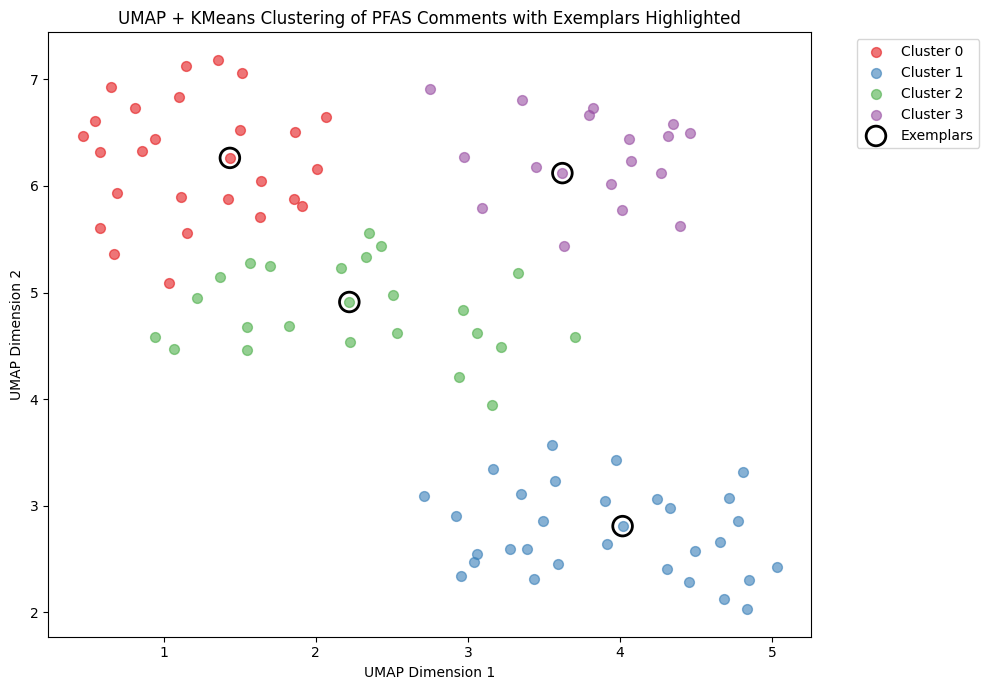

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

text_df = annotations_df[annotations_df["Combined Comments"].notna()].copy()

# embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(text_df["Combined Comments"].tolist(), normalize_embeddings=True)

# reduction to 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# KMeans clustering
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embedding_2d)
cluster_centers = kmeans.cluster_centers_

text_df["x"] = embedding_2d[:, 0]
text_df["y"] = embedding_2d[:, 1]
text_df["Cluster"] = cluster_labels

# exemplar selection
exemplar_indices = []
for cluster_id in range(num_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    cluster_points = embedding_2d[cluster_indices]
    center = cluster_centers[cluster_id].reshape(1, -1)
    distances = np.linalg.norm(cluster_points - center, axis=1)
    closest_idx = cluster_indices[np.argmin(distances)]
    exemplar_indices.append(closest_idx)

text_df["Is Exemplar"] = False
text_df.iloc[exemplar_indices, text_df.columns.get_loc("Is Exemplar")] = True
text_df["Cluster ID"] = text_df["Cluster"] + 1
exemplar_df = text_df.loc[text_df["Is Exemplar"]].copy()

# Plotting
plt.figure(figsize=(10, 7))
palette = sns.color_palette("Set1", num_clusters)

for cluster_id in range(num_clusters):
    group = text_df[text_df["Cluster"] == cluster_id]
    plt.scatter(group["x"], group["y"], color=palette[cluster_id], label=f"Cluster {cluster_id}", alpha=0.6, s=50)

plt.scatter(exemplar_df["x"], exemplar_df["y"],
            facecolors='none', edgecolors='black', linewidths=2, s=200, label="Exemplars")

plt.title("UMAP + KMeans Clustering of PFAS Comments with Exemplars Highlighted")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.show()

# exemplars chosen
exemplar_df.to_csv("selected_exemplars_umap_clusters.csv", index=False)
